# CIBUSmod impact analysis notebook
This notebook provides example functions and illustrations of how the data generated within the `run_scn` notebook can be selected and visualised 

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))
import CIBUSmod as cm

# Initialize the modules used to plot and analyze data
import pandas as pd

# To generate an interactive map with regions in Sweden that can be used to identify codes used in the inventory datasets, uncomment (remove #) and run the following cell

In [2]:
#FAI.plot_regions('sko')

## Initialize a `SoilDataExplore` scenario instance.
 The scenario instance get automatically populated with the datasets generated using the SoilData class.

In [3]:
FAI = cm.SoilDataExplore('FAI', verbose=True)

---Initializing variables---
+++Variables initialized---
---executing load_instance_state----
+++load_instance_state finished+++
---Loading inventory---
The following dataset variables have been set:
 input_inventory
The following dataset variables have been set:
 soc_inventory
The following dataset variables have been set:
 historic_inventory
The following dataset variables have been set:
 total_soc_inventory
No dataset variables have been loaded.
+++Inventory loaded+++
Initialization of food_as_industry instance of SoilData class complete


# Set the years for which SOC stocks should be compared in the subsequent calls
Set the years in the following cell to use the same initial and final year in all plots
The plots can be generated with both the 'conventional' and 'organic' systems included (2x2 plot) setting system='both', or for either system separately (as a 2x1 plot) specifying the name of the system. 

In [4]:
initial = '2020' # use strings to avoid timeseries interpretation issues
final = '2050' # use strings to avoid timeseries interpretation issues
# TODO: Add checks and corrective actions for parameters taking year as input to all methods

# Plot the SOC level and changes between two arbitrary years for a number of combinations 
(See comments behind input variables below) 

The following plots can be generated
initial_SOC_region
final_SOC_region
total_change_SOC_region
initial_SOC_ha
final_SOC_ha
total_change_SOC_ha
percentage_change_SOC_region
average_SOC_initial
average_SOC_final
initial_area
final_area
percentage_change_area


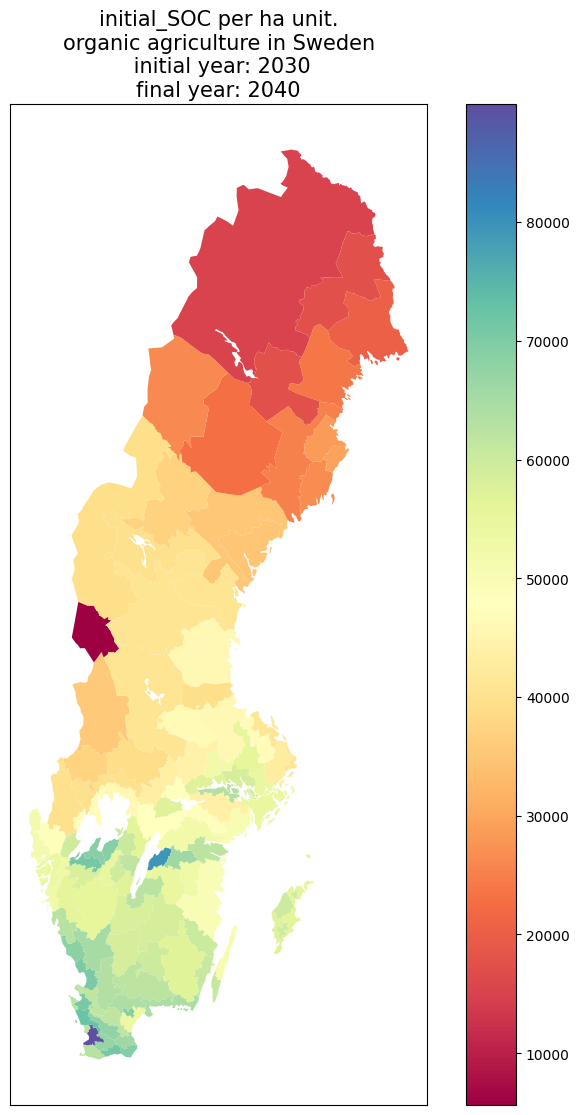

In [6]:
agr_system = 'organic' # 'all', 'conventional, 'organic'
startyear = '2030' # <inital> can be passed here  
finalyear = '2040' # <final> can be passed here
change_type = 'initial' # 'total_change', 'initial', 'final', 'percentage_change'
region_type = 'ha' # 'region', 'ha', 'area' ('area' can not be used with '_SOC')
soc_switch = '_SOC' # '_SOC', '' ('_SOC' can not be used with 'area', '_SOC' must be used with 'ha' and 'region)
dataset = f'{change_type}{soc_switch}_{region_type}'
out = FAI.plot_soc_map(system=agr_system, plot_set=dataset, colormap='Spectral', title=f"{change_type}{soc_switch} per {region_type} unit.\n{agr_system} agriculture in Sweden\n initial year: {startyear}\nfinal year: {finalyear}", save_as=f"{change_type}{soc_switch}_per_{region_type}_({agr_system} agriculture_initial year-{startyear}_final year-{finalyear}")

In [7]:
((out['final_area'].data - out['initial_area'].data) / out['initial_area'].data) * 100

array([ 22.38491032,  -7.04722493,  -8.59927075, -10.67009966,
        -8.85703956,  -8.90520747,  -9.21610942,  -8.99747606,
        -7.19852513,  -7.44863366,  -5.13406118,  -9.30471896,
        -8.42043555, -10.0062702 ,  -9.29540118, -10.20754488,
        -9.6322818 ,  -8.29891345,  -7.96073924,  -3.89327107,
        -4.99117035,  14.09406789,  -6.64794941,  -9.72462143,
        -2.77167758,  -6.27813727,  -6.96942285,   2.16283541,
       -10.9642352 ,  -6.51705529, -10.56949185,  -2.19908068,
        40.15970531,   4.79180604,  11.83099768,   3.63224495,
        -5.08679386,  -5.1120006 ,  -5.1321588 ,  27.47352979,
        -5.91023001,  -8.35219223,   1.38950009,  -6.80565149,
         1.6253785 ,  -6.16000568,  22.6431705 , -12.47156944,
       -12.19886853, -11.7614968 ,  -9.43974004,  -5.28878047,
        -6.77086402,  -6.94693   ,  -5.691397  , -12.73665053,
        -6.99275277,  -7.342554  , -10.68959732,  -8.68764533,
        -9.01853549, -10.83019575,  -9.4253391 , -10.88

# Compare percentual SOC stock change and cumulative CO2 emissions between two years for all regions

,geometry,values
111,"MULTIPOLYGON (((634777.724 6564377.723, 634829...",41237.957843
112,"MULTIPOLYGON (((712660.364 6622479.760, 712809...",40446.373903
311,"POLYGON ((662243.276 6655209.862, 662222.939 6...",55139.494711
312,"POLYGON ((662243.276 6655209.862, 662289.520 6...",47617.204806
321,"MULTIPOLYGON (((651514.264 6611417.290, 651863...",58090.671803
...,...,...
2419,"POLYGON ((513823.815 7166733.232, 513572.983 7...",39769.371898
2511,"MULTIPOLYGON (((813361.866 7247931.734, 811423...",36918.407663
2512,"MULTIPOLYGON (((888428.442 7375930.403, 888666...",35799.685684
2519,"POLYGON ((623117.545 7284224.654, 622991.632 7...",36848.805618


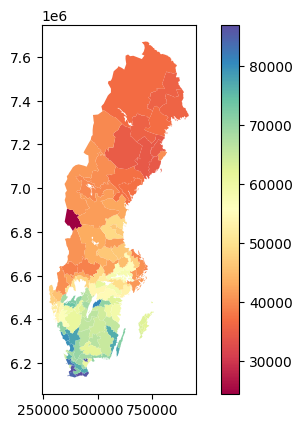

In [131]:
import geopandas as gpd
mask = FAI.total_soc_inventory['fraction'].str.contains('_kgc')

oldini_con = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2020', 'prod_system': 'conventional', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year']))
oldfin_con = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2050', 'prod_system': 'conventional', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year']))

old_con_change = (oldfin_con / oldini_con - 1) * 100

oldini_org = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2020', 'prod_system': 'organic', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year']))
oldfin_org = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2050', 'prod_system': 'organic', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year']))

old_org_change = (oldfin_org / oldini_org - 1) * 100

tot_areas_2020 = FAI.input_inventory.area_ha.sel({'input_year': '2020', 'scn': 'fai'}).sum(['crop','prod_system'])
tot_areas_2050 = FAI.input_inventory.area_ha.sel({'input_year': '2050', 'scn': 'fai'}).sum(['crop','prod_system'])

new_reg_ini = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2020', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year', 'prod_system']))
                                   
new_ha_ini = new_reg_ini / tot_areas_2020
new_reg_fin = initial_soc_level = (FAI.total_soc_inventory.tot_soc.
                            sel({'output_year': '2050', 'scn': 'fai'}).
                            where(mask, drop=True).
                            sum(['fraction', 'input_year', 'output_year', 'prod_system']))
new_ha_fin = new_reg_fin / tot_areas_2050 
total_average_ini = new_reg_ini.sum(['region']) / tot_areas_2020.sum(['region', 'input_year'])
total_average_fin = new_reg_ini.sum(['region']) / tot_areas_2050.sum(['region', 'input_year'])
total_average_ini.data, total_average_fin.data, total_average_fin.data / total_average_ini.data
new_perc_change = ((new_reg_fin - new_reg_ini) / new_reg_ini) * 100
test_data = pd.DataFrame(new_ha_fin.data, index=new_reg_ini.region.data.astype(str), columns=['values'])
MAP = cm.utils.plot.maps.MAP
MAP['sko']
kwargs = {'edgecolor' : 'none', 'column' : 'values', 'linewidth' : 0.1, 'legend' : True, 'cmap': 'Spectral'}
plotdata = pd.concat([MAP['sko'], test_data], axis=1)
to_plot = gpd.GeoDataFrame(plotdata, geometry='geometry')
to_plot.plot(**kwargs)
to_plot

1 potential outliers detected in the stock_change_series.
Run "FAI.outlier_report(output['soc_stock_change_series'])" for more info.
Or, if you want to test your luck directly:
 re-run the plot-method with the "mask_outlier" parameter set to True,
        (mask_outlier=True)
and add the number of the subplot to the "mask_subplots" parameter list
        (mask_subplots=[1,])
1 potential outliers detected in the co2_emissions_series.
Run "FAI.outlier_report(output['co2_emissions_series'])" for more info.
Or, if you want to test your luck directly:
 re-run the plot-method with the "mask_outlier" parameter set to True,
        (mask_outlier=True)
and add the number of the subplot to the "mask_subplots" parameter list
        (mask_subplots=[2,])
No outliers detected in area_change_series.
1 potential outliers detected in the area_change_perc_series.
Run "FAI.outlier_report(output['area_change_perc_series'])" for more info.
Or, if you want to test your luck directly:
 re-run the plot-method

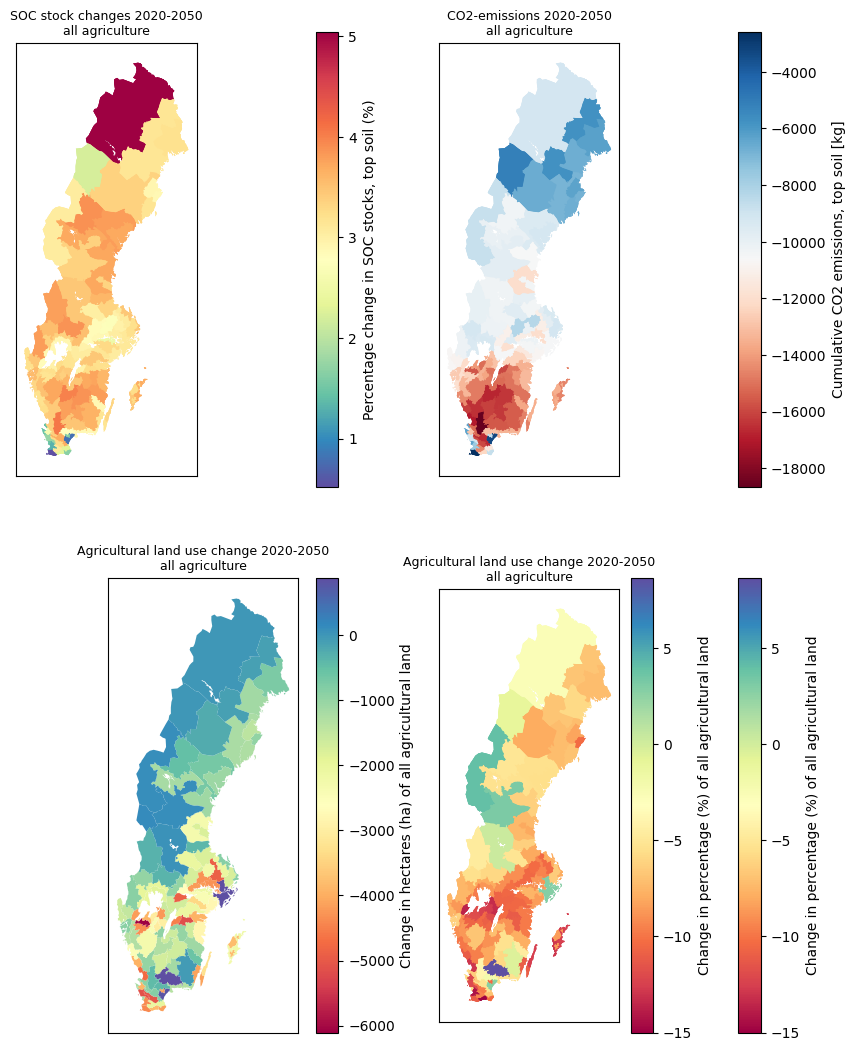

|--------------------------------------------------------|
|            Some summarizing statistics                 |
|                 for Sweden as a whole                  |
|--------------------------------------------------------|
TOTAL CO2-emissions due to agricultural SOC stock changes 2020-2050:
        -6692263150 kg of CO2
            which is equal to:  -6692263 Mg of CO2
                           or:  -7 Million Mg of CO2
                           or:  -223075 Mg of CO2 per year
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
TOTAL relative (%) SOC stock change between 2020 and 2050:
        1 % of SOC stocks in 2020
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
TOTAL absolute area change between 2020 and 2050:
        -214673 ha
            which is equal to:  -2146726729 m2
                           or:  -2147 km2
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
TOTAL relative (%) area change between 2020 and 2050:
        -9  % of agr

In [7]:
# To see all options uncomment and run line below
#FAI.plot_soc_co2_regions_map?
# Set the following variable to select whether to plot 'conventional' or 'organic' systems
agr_type = 'all' # 'organic' or 'conventional' or 'all'
output = FAI.plot_soc_co2_regions_map(initial_year=initial, final_year=final,save_as=f'SOC_CO2_all_regions_map_{initial}_{final}(ha, {agr_type})', system=agr_type, colormaps=['Spectral_r', 'RdBu', 'Spectral', 'Spectral'], width=10, height_scaling=1.3, standard_font=9, verbose=False, mask_outlier=True, mask_subplots=[1,2,4])

# Plot the SOC stocks in all regions for two separate years

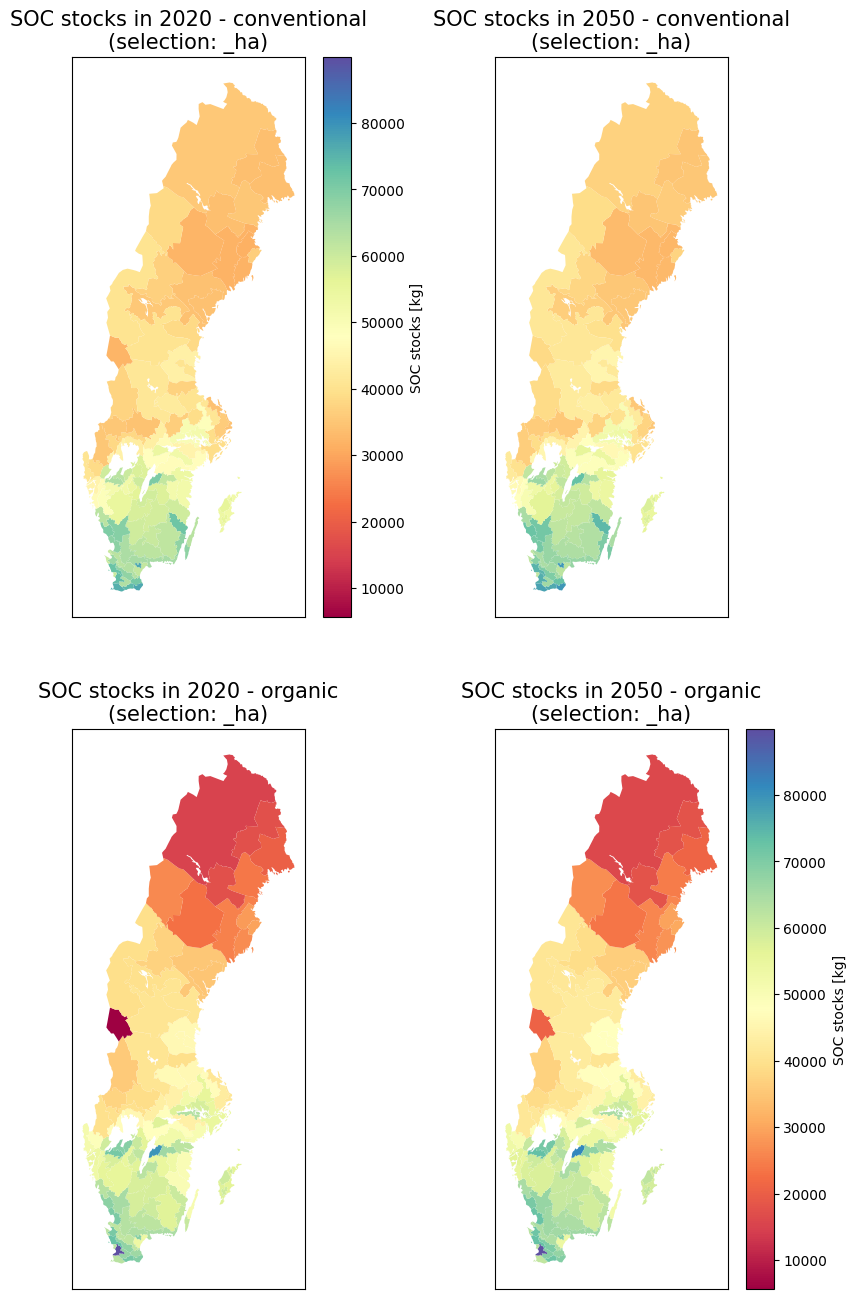

In [9]:
# Figure will be saved to '<save_as>.svg' and '<save_as>.png' in the data/soil/exported_results folder
# To see all options uncomment and run line below
#FAI.plot_soc_stock_maps?
# hint: colormap can be changed using the 'colormap' keyword. Some examples: 'YlOrBr_r'(default) 'YlGnBu'
## Available color maps 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

## uncomment to save output to figures
#FAI.plot_soc_stock_maps(system='both', colormap='Spectral', initial_year=initial, final_year=final,save_as=f'SOC_stocks_map_{initial}_{final}(ha)_both_systems', width=10, height_scaling=0.8, verbose=False)
## uncomment to NOT save output to figures
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic maps
FAI.plot_soc_stock_maps(system='both', colormap='Spectral', initial_year=initial, final_year=final, width=10, height_scaling=0.8, verbose=False)
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic horisontal bars
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=10, height_scaling=1.75, verbose=False, kind='barh', xlabel='SOC in top soil [kg]')
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic boxplot
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=12, height_scaling=0.3, verbose=False, kind='box', ylabel='SOC in top soil [kg]')
## 4 panes: comparison of SOC stocks 2020/2050 - conventional and organic histogram
#FAI.plot_soc_stock_maps(system='both', initial_year=initial, final_year=final, width=10, height_scaling=0.6, verbose=False, kind='hist', bins=40, xlabel='SOC in top soil [kg]')

## To detect outliers the 'outlier_detect' method can be used
A dataseries can be plotted either as a boxplot (default), or as a scatter plot, using a second series with the same coordinates for the y-axis. A Z-score test with summary statirstics can also be used to automatically detect outliers, based on a provided threshold key-argument. Default value is 3. 

Outliers automatically identified while running plots are also stored in an instance variable as a dict. 

In [10]:
FAI.outlier_detect?
for i in FAI.outliers.keys():
    print(i)

stock_change_series_num_outliers
stock_change_series_outlier_index
stock_change_series_outlier_positions
stock_change_series_dirty_series
stock_change_series_cleaned_series
co2_emissions_series_num_outliers
co2_emissions_series_outlier_index
co2_emissions_series_outlier_positions
co2_emissions_series_dirty_series
co2_emissions_series_cleaned_series
area_change_perc_series_num_outliers
area_change_perc_series_outlier_index
area_change_perc_series_outlier_positions
area_change_perc_series_dirty_series
area_change_perc_series_cleaned_series


# Create a single subplot with percentage change between two years for all regions

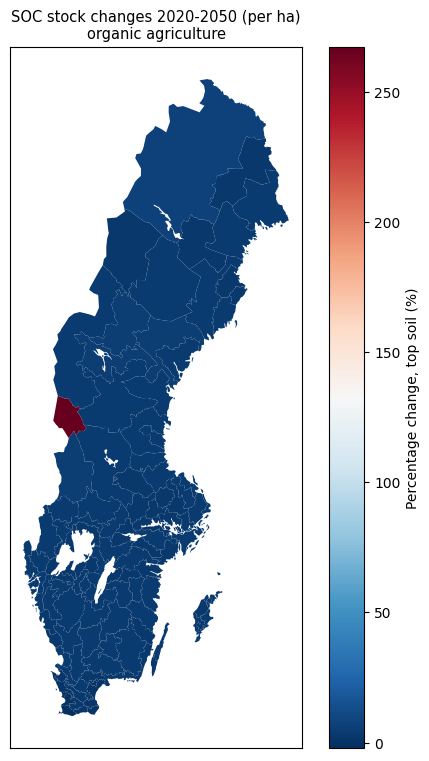

In [11]:
# Set the following variable to select whether to plot 'conventional' or 'organic' systems
agr_type = 'organic' # 'organic' or 'conventional'
stock_ser = FAI.plot_all_regions_map(colormap='RdBu_r', initial_year=initial, final_year=final, system=agr_type, save_as=f'SOC_change_{initial}_{final}', width=7, title=f'SOC stock changes {initial}-{final} (per ha)\n{agr_type} agriculture', legend_kwds={'label': 'Percentage change, top soil (%)'})

# Plot the SOC time series for historic input, new input and total input (historic + new) for a single sko

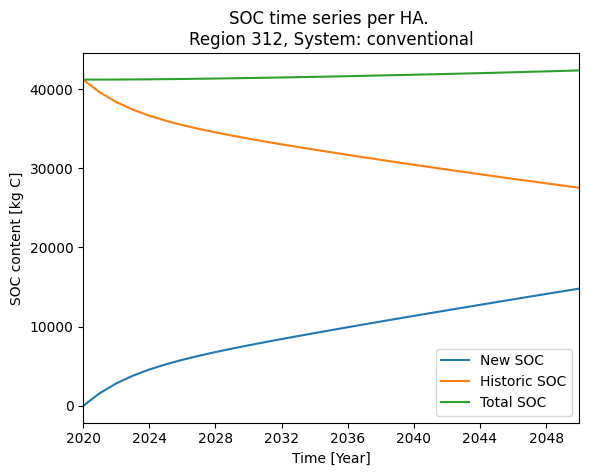

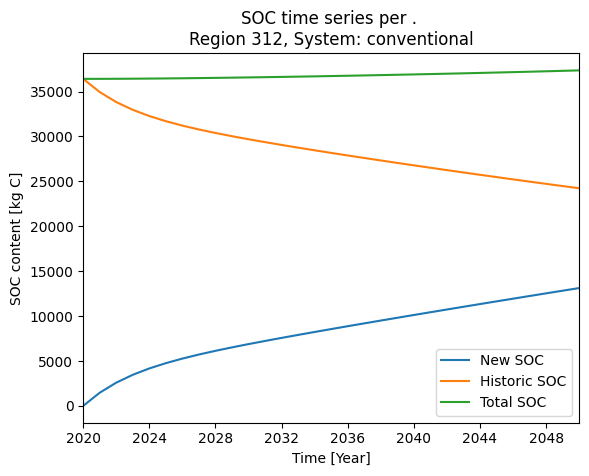

In [14]:
# To switch between results/ha and results/region(sko) use '_ha' or '_kgc' (adjust if input_df changes the use of suffix)
reg = 312
system = 'conventional'
sel1 = '_ha'
sel2 = 'crop_ha'
all_soc_fractions = FAI.plot_single_region_timeseries(sko=312, system='conventional', selection=sel1, save_as=f'Total_SOC_time_series_(sko-{reg}_system-{system}_selection-{sel2})', min_year=2020, max_year=2050)
crop_soc_fractions = FAI.plot_single_region_timeseries(sko=312, system='conventional', selection=sel2, save_as=f'crop_SOC_time_series_(sko-{reg}_system-{system}_selection-{sel2})', min_year=2020, max_year=2050)

# Plot and compare single fraction to the total SOC of a region
The `fraction` keyword must end exactly as the fraction that should be
To see available fractions run
list(FAI.total_soc_inventory['fraction'].values)

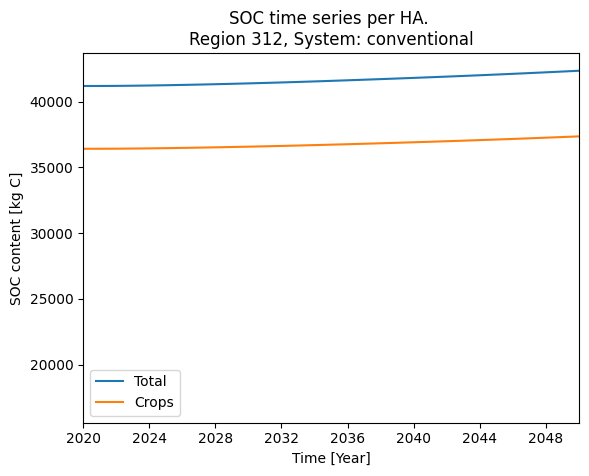

In [15]:
frac = 'crop_ha'
reg = 312
system = 'conventional'
output = FAI.plot_fraction_total_timeseries_comparison(sko=reg, system=system, selection='_ha', fraction=frac, fraction_name='Crops', min_year=2020, max_year=2050, save_as=f'comparison_total_vs_{frac}_timeseries_(sko-{reg}_system-{system})')

# Plot SOC stocks in initial and final years for different fractions, both conv. and org.

In [16]:
selection = FAI.show_variable_values()
sko = [item for item in selection if '_kgc' in item]
ha = [item for item in selection if '_ha' in item]
ha_manure = [item for item in ha if 'manure' in item]
ha_crop = [item for item in ha if 'crop' in item]
sko_manure = [item for item in sko if 'manure' in item]
sko_crop = [item for item in sko if 'crop' in item]

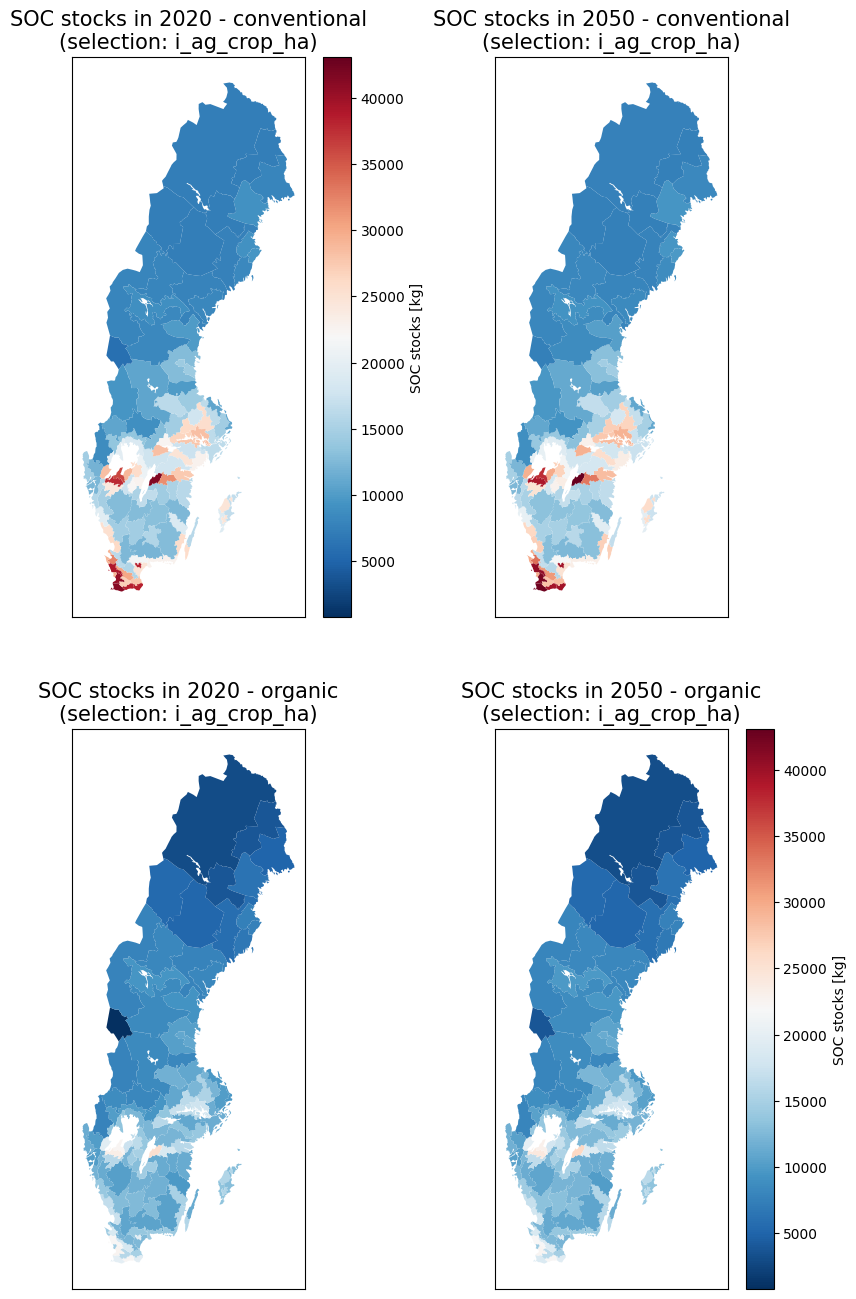

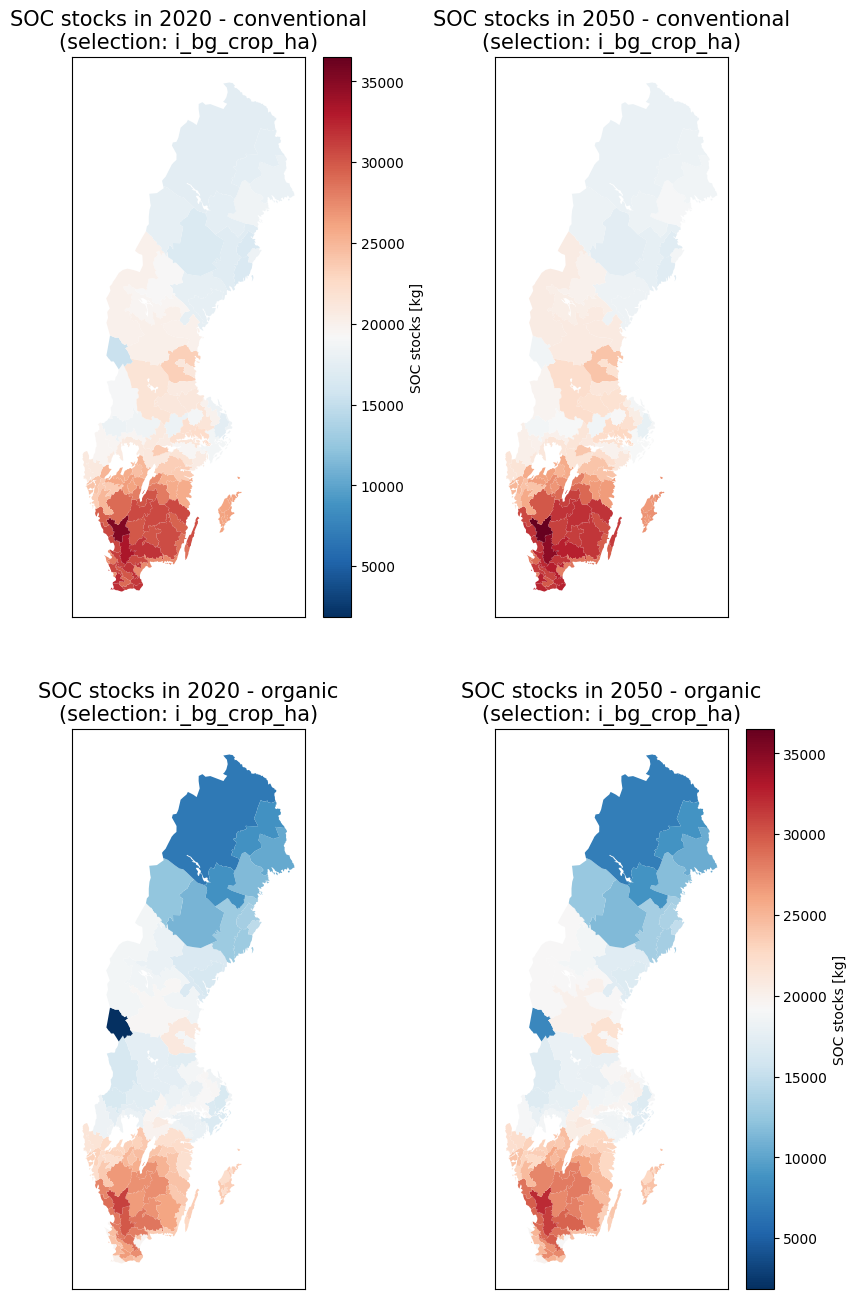

In [17]:
# set the plot_sel to any of the above variables
plot_sel = ha_crop
for i in plot_sel:
    FAI.plot_soc_stock_maps(system='both', colormap='RdBu_r', vers=i, initial_year=initial, final_year=final, width=10, height_scaling=0.8, verbose=False)

# Investigate the dataset interactively

In [13]:
FAI.total_soc_inventory

<xarray.Dataset> Size: 380MB
Dimensions:      (region: 106, output_year: 100, input_year: 32, fraction: 14,
                  prod_system: 2, scn: 1)
Coordinates:
  * region       (region) int32 424B 111 112 311 312 321 ... 2511 2512 2519 2521
  * output_year  (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * input_year   (input_year) datetime64[ns] 256B 2019-01-01 ... 2050-01-01
  * fraction     (fraction) object 112B 'i_ag_crop_ha' ... 'i_bg_crop_kgc'
  * prod_system  (prod_system) object 16B 'conventional' 'organic'
  * scn          (scn) object 8B 'fai'
Data variables:
    input_area   (scn, input_year, prod_system, region, fraction, output_year) float64 76MB ...
    y_pool       (scn, input_year, prod_system, region, fraction, output_year) float64 76MB ...
    o_pool       (scn, input_year, prod_system, region, fraction, output_year) float64 76MB ...
    tot_soc      (scn, input_year, prod_system, region, fraction, output_year) float64 76MB ...
    co2_flux     (scn, input_year, prod_system, region, fraction, output_year) float64 76MB ...

# To explore return values, work below this heading - to avoid messing up the notebook structure